# <center> Predicción de Precios en Bienes Raíces: Mercado Australiano
## <center> Regresión Avanzada con PyCaret y Modelos de Regularización

**Materia:** AI & MLOps  
**Universidad:** Universidad Católica Boliviana – San Pablo  
**Profesor:** Jheser Guzman Ph.D.  
**Integrantes del Grupo:**
* Rios Nuñez David Samuel
* Rivera Quisberth Juan Enrique
* Terceros Beltran Oscar Alvaro
* Torrez Azuga Marcelo

---

## Tabla de Contenido
1. [Introducción](#1.-Introducción)
2. [Comprensión del Negocio](#2.-Comprensión-del-Negocio)
3. [Comprensión de los Datos](#3.-Comprensión-de-los-Datos)
4. [Preparación de Datos](#4.-Preparación-de-Datos-Data-Wrangling)
5. [Análisis Exploratorio de Datos](#5.-Análisis-Exploratorio-de-Datos-EDA)
6. [Construcción del Modelo](#6.-Construcción-del-Modelo)
7. [Evaluación del Modelo](#7.-Evaluación-del-Modelo)
8. [Interpretabilidad del Modelo](#8.-Interpretabilidad-del-Modelo)
9. [Conclusiones y Recomendaciones](#9.-Conclusiones-y-Recomendaciones)


# 1. Introducción

### Descripción del Problema
El mercado de bienes raíces es altamente dinámico y está influenciado por una amplia gama de factores físicos, geográficos, económicos y de diseño. Para una empresa comercializadora de propiedades, estimar con precisión el valor real de mercado de una vivienda antes de realizar una transacción es crítico.

En este proyecto se aborda el problema de la empresa **Surprise Housing**, una compañía estadounidense que planea ingresar al mercado australiano adquiriendo viviendas subvaloradas para luego remodelarlas y venderlas a un precio competitivo.

Para guiar su estrategia de inversión, Surprise Housing requiere un modelo cuantitativo riguroso que no solo prediga con precisión los precios, sino que también proporcione interpretabilidad respecto a qué variables determinan dicho valor.

> **Nota metodológica sobre el dataset:** el caso de negocio se plantea para el mercado australiano, pero el dataset académico utilizado corresponde al conjunto Ames Housing. En este proyecto se utiliza como base histórica estructurada para demostrar el flujo completo de regresión avanzada: limpieza, EDA, ingeniería de características, comparación de modelos, ajuste de hiperparámetros e interpretabilidad.

### Objetivo General
* Desarrollar un modelo de regresión avanzada capaz de estimar el precio de venta de viviendas residenciales a partir de sus características físicas, de calidad, ubicación y condición de venta.

### Objetivos Específicos
* Realizar controles de calidad de datos: valores faltantes, duplicados, variables redundantes e inconsistencias.
* Crear variables derivadas con interpretación comercial clara.
* Comparar diferentes modelos de regresión usando PyCaret.
* Ajustar hiperparámetros de modelos regularizados Ridge, Lasso y ElasticNet.
* Evaluar el modelo final usando métricas adecuadas para regresión.
* Explicar las variables más importantes del modelo en términos simples para el negocio.


# 2. Comprensión del Negocio

### Problema de Negocio
El modelo operativo de **Surprise Housing** depende de un margen comercial obtenido mediante la compra-remodelación-venta de viviendas. Los principales riesgos y problemas del negocio son:
* **Riesgo de Sobreprecio:** Pagar un precio mayor por una propiedad que no ofrece el potencial de revalorización necesario para cubrir los costos de adquisición y remodelación, destruyendo el margen de ganancia.
* **Costo de Oportunidad:** Dejar pasar propiedades subvaloradas por no contar con una herramienta rápida y precisa para estimar su valor real de mercado.
* **Falta de Conocimiento Local:** Siendo Surprise Housing una firma estadounidense, carece de la intuición histórica del mercado inmobiliario en Australia, lo que hace indispensable el uso de modelos empíricos basados en datos locales para guiar la inversión.

### Impacto de la Predicción
Contar con una predicción de precio confiable actúa como un filtro financiero estratégico. Permite a los analistas inmobiliarios:
1. Identificar instantáneamente anomalías de precio (casas cuyo precio de lista es significativamente menor al valor real predicho).
2. Estimar con precisión el precio máximo de compra para asegurar la rentabilidad objetivo del proyecto de renovación.
3. Comprender cómo la remodelación de ciertos atributos (ej. mejorar la cocina o expandir el área habitable) impactará directamente en el precio de venta final.

### Beneficios del Modelo
* **Automatización y Eficiencia:** Reducción drástica del tiempo necesario para evaluar la rentabilidad de portafolios de propiedades de manera masiva.
* **Reducción de Sesgos:** Decisiones basadas en evidencia estadística objetiva en lugar de valoraciones subjetivas de tasadores tradicionales.
* **Optimización de Remodelaciones:** Priorizar inversiones en los atributos de vivienda que el modelo identifique como los más significativos para maximizar el precio de venta final.


# 3. Comprensión de los Datos

### Descripción del Dataset
El dataset histórico cuenta con **1460 observaciones** y **81 columnas** incluyendo el identificador `Id` y la variable objetivo `SalePrice`. Este conjunto registra variables físicas, cualitativas y de venta de viviendas residenciales.

### Aclaración de Contexto
Aunque el enunciado del proyecto usa el contexto comercial de Surprise Housing en Australia, el diccionario de datos describe vecindarios dentro de **Ames city limits**. Para fines académicos, se mantiene el caso de negocio propuesto y se utiliza el dataset como una base tabular representativa de transacciones inmobiliarias.

### Categorización de las Variables
* **Variables Numéricas Continuas:** `LotArea`, `GrLivArea`, `TotalBsmtSF`, `GarageArea`, entre otras.
* **Variables Numéricas Discretas:** `YearBuilt`, `FullBath`, `BedroomAbvGr`, `Fireplaces`, entre otras.
* **Variables Categóricas Nominales:** `Neighborhood`, `MSZoning`, `Foundation`, `SaleCondition`, entre otras.
* **Variables Categóricas Ordinales:** `OverallQual`, `ExterQual`, `KitchenQual`, `BsmtQual`, `GarageQual`, entre otras.

### Variable Objetivo
La variable objetivo es `SalePrice`, precio final de venta de la vivienda. Debido a su sesgo positivo, se aplica posteriormente una transformación logarítmica para estabilizar la varianza y mejorar el desempeño de los modelos de regresión.


# 4. Preparación de Datos (Data Wrangling)

En esta sección se limpian los datos y se preparan para modelado. La preparación sigue los lineamientos de calidad solicitados en la rúbrica: detección de nulos, imputación justificada, revisión de duplicados, creación de nuevas variables y transformación a un formato apto para análisis.

### Decisiones de Limpieza
1. **Eliminación de Identificador:** `Id` se elimina porque es una clave secuencial sin valor predictivo.
2. **Imputación de Categóricas Especiales:** en columnas como `PoolQC`, `Fence`, `Alley`, `BsmtQual` y `GarageQual`, el valor faltante representa ausencia del atributo. Se reemplaza por `NoFeature` para evitar que Pandas vuelva a interpretarlo como nulo al recargar el CSV.
3. **Imputación de `LotFrontage`:** se usa la mediana por `Neighborhood`, ya que el frente de calle depende del vecindario.
4. **Imputación Específica:** `MasVnrArea` se imputa con 0, `MasVnrType` con `NoFeature`, `GarageYrBlt` con `YearBuilt` y `Electrical` con la moda.
5. **Duplicados:** se revisan y eliminan si existen.
6. **Ingeniería de Características:** se crean `HouseAge`, `RemodAge`, `TotalSF`, `TotalBath` y `HasPool`.
7. **Transformación Logarítmica:** `SalePrice` se transforma con `np.log1p()` para reducir el sesgo de la distribución.


## 4.1 Carga de librerías y lectura del dataset
Esta celda importa las librerías base, configura la visualización numérica y carga el dataset original desde la carpeta `_data`.


In [1]:
# Import required data libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.2f}'.format

# Define dataset path
DATA_FILE_PATH = '_data/dataset.csv'

# Load raw dataset
raw_data = pd.read_csv(DATA_FILE_PATH)
print(f"Loaded dataset dimensions: {raw_data.shape}")
display(raw_data.head())


Loaded dataset dimensions: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 4.2 Control inicial de calidad de datos
Antes de imputar, se identifican columnas con valores faltantes y se revisa si existen registros duplicados. Esta evidencia permite justificar las acciones de limpieza posteriores.


In [2]:
# Missing-value report before cleaning
missing_summary = raw_data.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

missing_table_before = pd.DataFrame({
    'missing_count': missing_summary,
    'missing_percentage': (missing_summary / len(raw_data) * 100).round(2)
})

print(f"Columns with missing values before cleaning: {missing_table_before.shape[0]}")
display(missing_table_before)

# Duplicate rows before cleaning
raw_duplicates_count = raw_data.duplicated().sum()
print(f"Duplicate rows before cleaning: {raw_duplicates_count}")


Columns with missing values before cleaning: 19


,missing_count,missing_percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


Duplicate rows before cleaning: 0


## 4.3 Limpieza, imputación e ingeniería de características
Se aplica la limpieza principal del dataset. Las etiquetas `NoFeature` representan ausencia real del atributo, por ejemplo: sin piscina, sin garaje, sin sótano o sin chimenea.


In [3]:
# Copy dataset for preprocessing
df_cleaned = raw_data.copy()

# 1. Drop unique identifier
if 'Id' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['Id'])

# 2. Impute categorical variables where NA has a valid business meaning
# Use 'NoFeature' instead of 'None' because Pandas may read the string 'None' as NA later.
no_feature_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]

for col in no_feature_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna('NoFeature')

# 3. Impute numerical and categorical columns with localized/business rules
if 'LotFrontage' in df_cleaned.columns:
    df_cleaned['LotFrontage'] = df_cleaned.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    df_cleaned['LotFrontage'] = df_cleaned['LotFrontage'].fillna(df_cleaned['LotFrontage'].median())

if 'MasVnrArea' in df_cleaned.columns:
    df_cleaned['MasVnrArea'] = df_cleaned['MasVnrArea'].fillna(0.0)

if 'MasVnrType' in df_cleaned.columns:
    df_cleaned['MasVnrType'] = df_cleaned['MasVnrType'].fillna('NoFeature')

if 'GarageYrBlt' in df_cleaned.columns:
    df_cleaned['GarageYrBlt'] = df_cleaned['GarageYrBlt'].fillna(df_cleaned['YearBuilt'])

if 'Electrical' in df_cleaned.columns:
    df_cleaned['Electrical'] = df_cleaned['Electrical'].fillna(df_cleaned['Electrical'].mode()[0])

# 4. Check and remove duplicates if any
duplicates_count = df_cleaned.duplicated().sum()
print(f"Duplicate rows after removing Id: {duplicates_count}")
if duplicates_count > 0:
    df_cleaned = df_cleaned.drop_duplicates()

# 5. Feature Engineering
df_cleaned['HouseAge'] = df_cleaned['YrSold'] - df_cleaned['YearBuilt']
df_cleaned['RemodAge'] = df_cleaned['YrSold'] - df_cleaned['YearRemodAdd']
df_cleaned['TotalSF'] = df_cleaned['1stFlrSF'] + df_cleaned['2ndFlrSF'] + df_cleaned['TotalBsmtSF']
df_cleaned['TotalBath'] = (
    df_cleaned['FullBath'] + 0.5 * df_cleaned['HalfBath'] +
    df_cleaned['BsmtFullBath'] + 0.5 * df_cleaned['BsmtHalfBath']
)
df_cleaned['HasPool'] = (df_cleaned['PoolArea'] > 0).astype(int)

# 6. Log transformation of target variable
df_cleaned['SalePrice'] = np.log1p(df_cleaned['SalePrice'])

print(f"Preprocessed dataset shape: {df_cleaned.shape}")
display(df_cleaned.head())


Duplicate rows after removing Id: 0
Preprocessed dataset shape: (1460, 85)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodAge,TotalSF,TotalBath,HasPool
0,60,RL,65.00,8450,Pave,NoFeature,Reg,Lvl,AllPub,Inside,...,2,2008,WD,Normal,12.25,5,5,2566,3.50,0
1,20,RL,80.00,9600,Pave,NoFeature,Reg,Lvl,AllPub,FR2,...,5,2007,WD,Normal,12.11,31,31,2524,2.50,0
2,60,RL,68.00,11250,Pave,NoFeature,IR1,Lvl,AllPub,Inside,...,9,2008,WD,Normal,12.32,7,6,2706,3.50,0
3,70,RL,60.00,9550,Pave,NoFeature,IR1,Lvl,AllPub,Corner,...,2,2006,WD,Abnorml,11.85,91,36,2473,2.00,0
4,60,RL,84.00,14260,Pave,NoFeature,IR1,Lvl,AllPub,FR2,...,12,2008,WD,Normal,12.43,8,8,3343,3.50,0


## 4.4 Verificación posterior y guardado del dataset limpio
Después de la imputación, se verifica que no queden valores faltantes. Luego se guarda el dataset procesado como `cleaned_dataset.csv`.


In [4]:
# Missing-value report after cleaning
remaining_missing = df_cleaned.isnull().sum()
remaining_missing_table = pd.DataFrame({
    'remaining_missing_values': remaining_missing[remaining_missing > 0]
})

print(f"Remaining missing values after cleaning: {remaining_missing.sum()}")
if remaining_missing_table.empty:
    print("No remaining missing values were found after preprocessing.")
else:
    display(remaining_missing_table)

# Save the preprocessed dataset
os.makedirs('_data', exist_ok=True)
cleaned_path = '_data/cleaned_dataset.csv'
df_cleaned.to_csv(cleaned_path, index=False)
print(f"Cleaned dataset saved successfully to '{cleaned_path}'")

# Reload verification: 'NoFeature' should not be parsed as missing by Pandas
reloaded_cleaned = pd.read_csv(cleaned_path)
print(f"Missing values after reloading cleaned CSV: {reloaded_cleaned.isnull().sum().sum()}")


Remaining missing values after cleaning: 0
No remaining missing values were found after preprocessing.
Cleaned dataset saved successfully to '_data/cleaned_dataset.csv'
Missing values after reloading cleaned CSV: 0


# 5. Análisis Exploratorio de Datos (EDA)

Realizamos un análisis visual para comprender el comportamiento del precio de venta y su relación con variables de tamaño, calidad y antigüedad. Los gráficos se separan en celdas independientes para facilitar la lectura del notebook.

> **Nota sobre outliers:** en este notebook los outliers se analizan visualmente, pero no se eliminan automáticamente. Se mantienen porque pueden representar propiedades reales de alto valor. Para reducir su influencia, se usa transformación logarítmica, escalado robusto y modelos no lineales/regularizados.


## 5.1 Distribución de la variable objetivo
Se compara `SalePrice` en escala original contra su transformación logarítmica. La segunda distribución es más simétrica y adecuada para regresión.


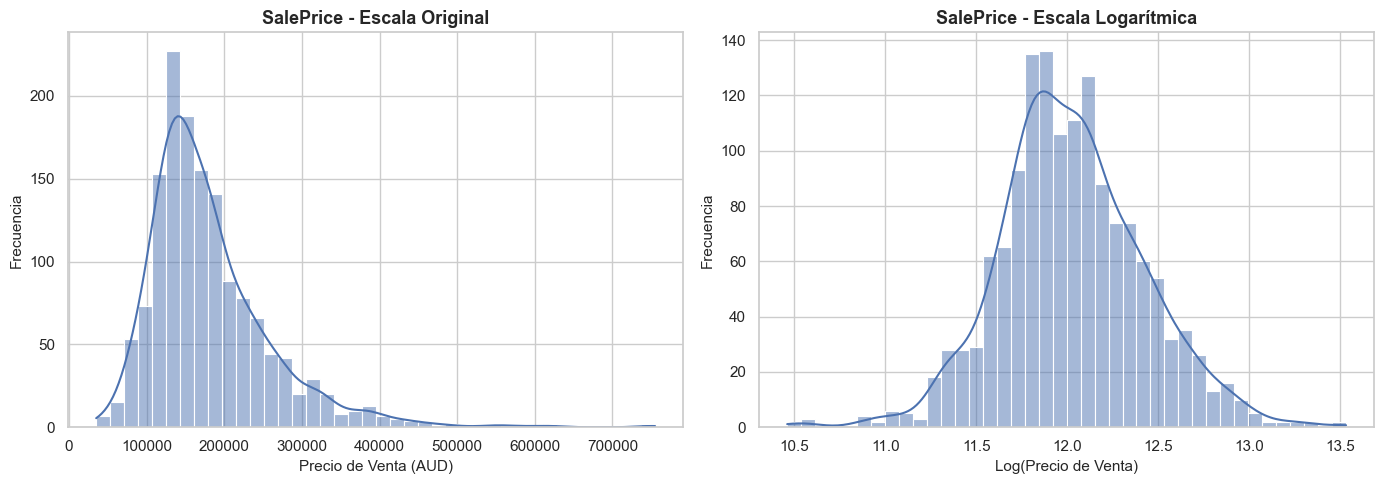

In [5]:
# Set seaborn theme for plots
sns.set_theme(style='whitegrid')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(raw_data['SalePrice'], kde=True, bins=40)
plt.title('SalePrice - Escala Original', fontsize=13, fontweight='bold')
plt.xlabel('Precio de Venta (AUD)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)

plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['SalePrice'], kde=True, bins=40)
plt.title('SalePrice - Escala Logarítmica', fontsize=13, fontweight='bold')
plt.xlabel('Log(Precio de Venta)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)

plt.tight_layout()
plt.show()


## 5.2 Matriz de correlación de variables numéricas
Se observan las variables numéricas más relacionadas con `SalePrice`. Esto ayuda a detectar predictores importantes y posibles redundancias.


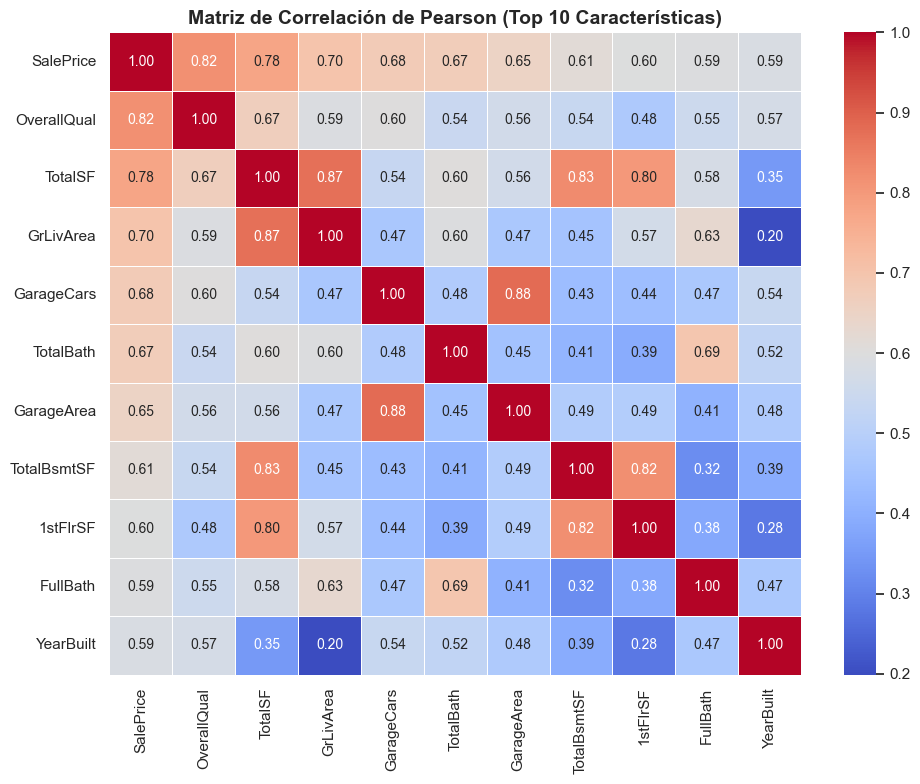

In [6]:
numeric_df = df_cleaned.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
top_features = correlation_matrix['SalePrice'].sort_values(ascending=False).index[:11]

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Matriz de Correlación de Pearson (Top 10 Características)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5.3 Relación entre calidad general y precio
`OverallQual` resume la calidad de materiales y acabados. Comercialmente, esta variable permite entender cómo la calidad de construcción impacta el precio.


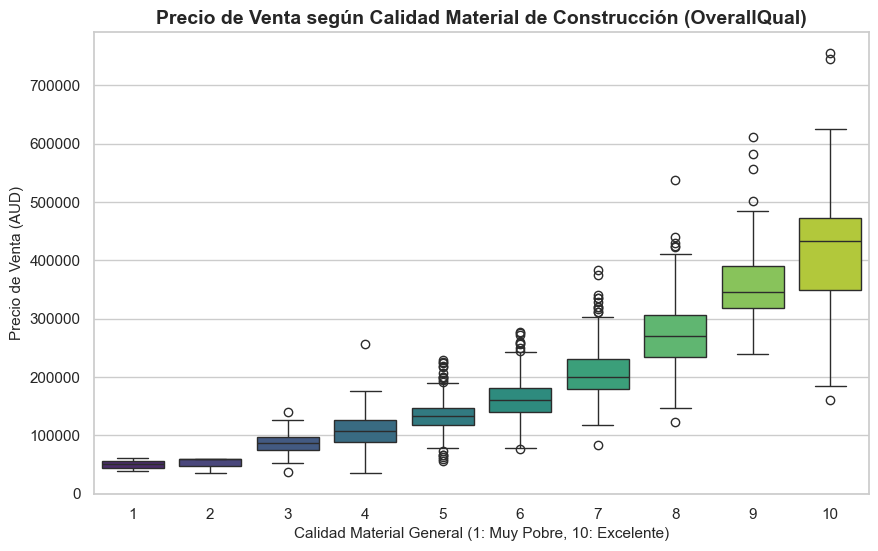

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=raw_data, palette='viridis')
plt.title('Precio de Venta según Calidad Material de Construcción (OverallQual)', fontsize=14, fontweight='bold')
plt.xlabel('Calidad Material General (1: Muy Pobre, 10: Excelente)', fontsize=11)
plt.ylabel('Precio de Venta (AUD)', fontsize=11)
plt.show()


## 5.4 Análisis visual de outliers
Este gráfico permite revisar propiedades con mucha superficie habitable o precios atípicos. Se utiliza como diagnóstico, no como eliminación automática.


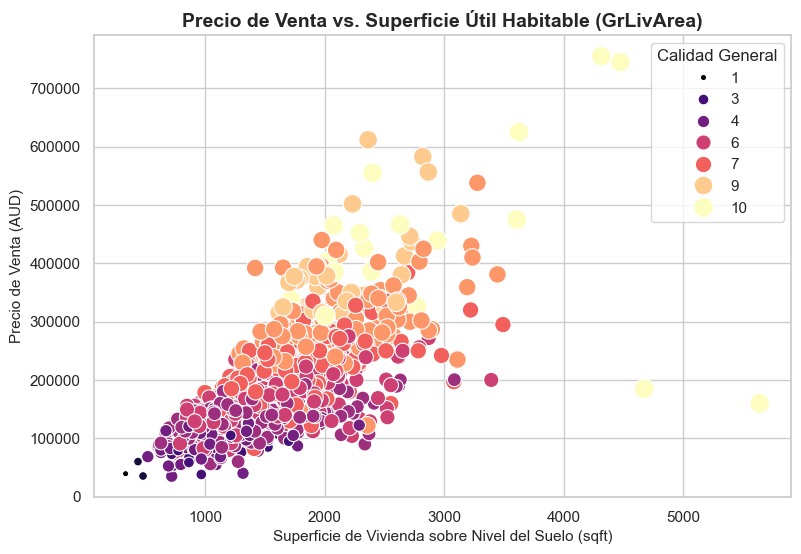

In [8]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    data=raw_data,
    hue='OverallQual',
    palette='magma',
    size='OverallQual',
    sizes=(20, 200)
)
plt.title('Precio de Venta vs. Superficie Útil Habitable (GrLivArea)', fontsize=14, fontweight='bold')
plt.xlabel('Superficie de Vivienda sobre Nivel del Suelo (sqft)', fontsize=11)
plt.ylabel('Precio de Venta (AUD)', fontsize=11)
plt.legend(title='Calidad General')
plt.show()


## 5.5 Estadísticas descriptivas de variables clave
Se resumen la variable objetivo y las nuevas métricas creadas para validar rangos y comportamiento general.


In [9]:
print('Estadísticas descriptivas de variables clave:')
df_key_vars = df_cleaned[['SalePrice', 'HouseAge', 'RemodAge', 'TotalSF', 'TotalBath']].copy()
df_key_vars['SalePrice'] = np.expm1(df_key_vars['SalePrice'])
display(df_key_vars.describe())


Estadísticas descriptivas de variables clave:


,SalePrice,HouseAge,RemodAge,TotalSF,TotalBath
count,1460.00,1460.00,1460.00,1460.00,1460.00
mean,180921.20,36.55,22.95,2567.05,2.21
std,79442.50,30.25,20.64,821.71,0.79
min,34900.00,0.00,-1.00,334.00,1.00
25%,129975.00,8.00,4.00,2009.50,2.00
50%,163000.00,35.00,14.00,2474.00,2.00
75%,214000.00,54.00,41.00,3004.00,2.50
max,755000.00,136.00,60.00,11752.00,6.00


# 6. Construcción del Modelo

Utilizamos **PyCaret** para construir un flujo reproducible de regresión:
1. Configuración del experimento con partición 70/30.
2. Codificación automática de variables categóricas, incluyendo variables dummy cuando corresponde.
3. Normalización robusta y remoción de multicolinealidad.
4. Comparación de múltiples algoritmos.
5. Ajuste fino de Ridge, Lasso y ElasticNet.
6. Selección y ajuste del mejor modelo global.


## 6.1 Configuración del experimento en PyCaret
PyCaret prepara automáticamente las variables categóricas mediante encoding interno. Esto cubre la creación de variables dummy cuando corresponde y evita hacerlo manualmente antes del modelado.


In [10]:
from pycaret.regression import *

print('Initializing PyCaret Setup...')
exp_reg = setup(
    data=df_cleaned,
    target='SalePrice',
    train_size=0.7,
    session_id=42,
    normalize=True,
    normalize_method='robust',
    remove_multicollinearity=True,
    multicollinearity_threshold=0.90,
    verbose=True
)

# Optional verification of transformed feature space after PyCaret preprocessing
try:
    X_train_transformed = get_config('X_train_transformed')
    print(f"Transformed training matrix shape: {X_train_transformed.shape}")
except Exception as error:
    print(f"Transformed feature matrix could not be displayed: {error}")


Initializing PyCaret Setup...


,Description,Value
0,Session id,42
1,Target,SalePrice
2,Target type,Regression
3,Original data shape,"(1460, 85)"
4,Transformed data shape,"(1460, 284)"
5,Transformed train set shape,"(1021, 284)"
6,Transformed test set shape,"(439, 284)"
7,Numeric features,41
8,Categorical features,43
9,Preprocess,True


Transformed training matrix shape: (1021, 283)


## 6.2 Comparación de modelos
Se entrenan varios modelos de regresión con validación cruzada y se seleccionan los tres mejores según desempeño predictivo.


In [11]:
print('--- Comparing All Regression Models ---')
best_models = compare_models(n_select=3, sort='R2')

print('Top models returned by PyCaret:')
display(best_models)


--- Comparing All Regression Models ---


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.0880,0.0179,0.1317,0.8834,0.0102,0.0074,0.3920
lightgbm,Light Gradient Boosting Machine,0.0911,0.0181,0.1329,0.8818,0.0103,0.0076,1.4980
et,Extra Trees Regressor,0.0965,0.0208,0.1424,0.8646,0.0110,0.0081,0.7130
rf,Random Forest Regressor,0.0989,0.0217,0.1451,0.8600,0.0112,0.0083,0.5420
br,Bayesian Ridge,0.0936,0.0240,0.1476,0.8412,0.0113,0.0078,0.2270
ridge,Ridge Regression,0.0965,0.0267,0.1545,0.8228,0.0118,0.0081,0.2370
ada,AdaBoost Regressor,0.1315,0.0306,0.1729,0.8021,0.0133,0.0110,0.4670
omp,Orthogonal Matching Pursuit,0.1033,0.0298,0.1631,0.8006,0.0124,0.0086,0.2360
dt,Decision Tree Regressor,0.1513,0.0467,0.2149,0.6915,0.0167,0.0127,0.2330
knn,K Neighbors Regressor,0.1634,0.0587,0.2397,0.6246,0.0184,0.0136,0.3340


Top models returned by PyCaret:


[GradientBoostingRegressor(random_state=42),
 LGBMRegressor(n_jobs=-1, random_state=42),
 ExtraTreesRegressor(n_jobs=-1, random_state=42)]

## 6.3 Modelos lineales regularizados base
Se crean modelos Ridge, Lasso y ElasticNet para analizar regularización y multicolinealidad.


In [12]:
print('--- Training Regularized Linear Models ---')
ridge = create_model('ridge')
lasso = create_model('lasso')
en = create_model('en')


--- Training Regularized Linear Models ---


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0935,0.0195,0.1396,0.8826,0.0109,0.0078
1,0.0779,0.0112,0.1057,0.9253,0.0081,0.0065
2,0.1075,0.0383,0.1958,0.7449,0.0147,0.0090
3,0.1162,0.0772,0.2779,0.5177,0.0200,0.0097
4,0.1144,0.0261,0.1617,0.8801,0.0129,0.0097
5,0.0832,0.0159,0.1262,0.8976,0.0096,0.0069
6,0.1004,0.0168,0.1295,0.8718,0.0100,0.0084
7,0.0856,0.0123,0.1110,0.9215,0.0086,0.0072
8,0.1069,0.0393,0.1984,0.6572,0.0154,0.0089


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3064,0.1647,0.4058,0.0080,0.0310,0.0254
1,0.3020,0.1468,0.3832,0.0196,0.0293,0.0249
2,0.2951,0.1516,0.3893,-0.0089,0.0300,0.0246
3,0.3132,0.1537,0.3921,0.0400,0.0299,0.0260
4,0.3402,0.2077,0.4557,0.0474,0.0355,0.0287
5,0.3149,0.1495,0.3867,0.0385,0.0298,0.0264
6,0.2824,0.1273,0.3568,0.0271,0.0273,0.0235
7,0.3108,0.1585,0.3981,-0.0104,0.0305,0.0259
8,0.2725,0.1156,0.3401,-0.0075,0.0260,0.0226


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3061,0.1611,0.4013,0.0296,0.0307,0.0254
1,0.3040,0.1473,0.3838,0.0160,0.0293,0.0251
2,0.2975,0.1554,0.3941,-0.0341,0.0304,0.0248
3,0.3123,0.1524,0.3904,0.0483,0.0298,0.0259
4,0.3392,0.2053,0.4531,0.0582,0.0353,0.0286
5,0.3124,0.1472,0.3837,0.0534,0.0295,0.0262
6,0.2816,0.1272,0.3566,0.0284,0.0273,0.0234
7,0.3103,0.1591,0.3989,-0.0145,0.0306,0.0258
8,0.2665,0.1104,0.3322,0.0385,0.0254,0.0221


## 6.4 Ajuste fino de hiperparámetros de regularización
Se usan grillas personalizadas para encontrar el mejor valor de `alpha` o `lambda`. En ElasticNet también se ajusta `l1_ratio`.


In [13]:
ridge_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 30.0, 50.0, 100.0]}
lasso_grid = {'alpha': [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}
en_grid = {
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]
}

print('--- Tuning Regularized Linear Models with Fine Grids ---')
tuned_ridge = tune_model(ridge, custom_grid=ridge_grid)
tuned_lasso = tune_model(lasso, custom_grid=lasso_grid)
tuned_en = tune_model(en, custom_grid=en_grid)

print('\nOptimal Regularization Parameters:')
print(f"Optimal Ridge alpha (lambda): {tuned_ridge.alpha}")
print(f"Optimal Lasso alpha (lambda): {tuned_lasso.alpha}")
print(f"Optimal ElasticNet alpha (lambda): {tuned_en.alpha}, l1_ratio: {tuned_en.l1_ratio}")


--- Tuning Regularized Linear Models with Fine Grids ---


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0978,0.0204,0.1427,0.8773,0.0110,0.0082
1,0.0820,0.0122,0.1104,0.9186,0.0085,0.0068
2,0.0931,0.0315,0.1775,0.7902,0.0133,0.0078
3,0.1089,0.0660,0.2568,0.5880,0.0186,0.0091
4,0.1069,0.0258,0.1606,0.8818,0.0129,0.0091
5,0.0786,0.0115,0.1073,0.9259,0.0083,0.0066
6,0.1025,0.0157,0.1254,0.8798,0.0097,0.0085
7,0.0854,0.0111,0.1053,0.9294,0.0082,0.0071
8,0.0957,0.0348,0.1866,0.6966,0.0145,0.0079


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0888,0.0171,0.1308,0.8969,0.0103,0.0075
1,0.0758,0.0108,0.1037,0.9282,0.0080,0.0063
2,0.0958,0.0389,0.1971,0.7413,0.0146,0.0080
3,0.1080,0.0713,0.2670,0.5548,0.0192,0.0090
4,0.1004,0.0231,0.1520,0.8940,0.0123,0.0085
5,0.0763,0.0174,0.1320,0.8879,0.0100,0.0063
6,0.0909,0.0131,0.1143,0.9001,0.0088,0.0076
7,0.0780,0.0097,0.0984,0.9382,0.0077,0.0065
8,0.0847,0.0195,0.1398,0.8298,0.0108,0.0071


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0949,0.0186,0.1363,0.8880,0.0106,0.0079
1,0.0806,0.0119,0.1092,0.9203,0.0084,0.0067
2,0.0949,0.0353,0.1880,0.7649,0.0139,0.0079
3,0.1099,0.0705,0.2655,0.5599,0.0192,0.0092
4,0.1024,0.0244,0.1562,0.8881,0.0126,0.0087
5,0.0766,0.0120,0.1096,0.9227,0.0084,0.0064
6,0.0946,0.0140,0.1182,0.8932,0.0091,0.0079
7,0.0803,0.0098,0.0992,0.9372,0.0077,0.0067
8,0.0951,0.0299,0.1728,0.7398,0.0134,0.0079


Fitting 10 folds for each of 10 candidates, totalling 100 fits

Optimal Regularization Parameters:
Optimal Ridge alpha (lambda): 20.0
Optimal Lasso alpha (lambda): 0.0005
Optimal ElasticNet alpha (lambda): 0.001, l1_ratio: 0.8


## 6.5 Ajuste del mejor modelo global
Después de comparar algoritmos, se ajusta el mejor modelo identificado por PyCaret y se finaliza para uso posterior.


In [14]:
best_model = best_models[0] if isinstance(best_models, list) else best_models
print(f"Tuning the best overall model: {best_model}")

tuned_best_model = tune_model(best_model)
final_model = finalize_model(tuned_best_model)

print('Final model trained and locked for production deployment.')


Tuning the best overall model: GradientBoostingRegressor(random_state=42)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0938,0.0217,0.1473,0.8693,0.0113,0.0078
1,0.0801,0.0125,0.1117,0.9167,0.0086,0.0067
2,0.0959,0.0255,0.1597,0.8302,0.0121,0.0080
3,0.0991,0.0252,0.1588,0.8425,0.0121,0.0083
4,0.1017,0.0278,0.1666,0.8727,0.0133,0.0086
5,0.0783,0.0134,0.1156,0.9141,0.0088,0.0065
6,0.0905,0.0155,0.1244,0.8817,0.0096,0.0075
7,0.0840,0.0140,0.1184,0.9106,0.0092,0.0070
8,0.0758,0.0148,0.1215,0.8714,0.0094,0.0063


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Final model trained and locked for production deployment.


# 7. Evaluación del Modelo

La evaluación se realiza sobre el conjunto holdout del 30%. Como el modelo fue entrenado con `SalePrice` en escala logarítmica, las predicciones se convierten de vuelta a la escala monetaria usando `np.expm1()`.

### Métricas usadas
* **R²:** proporción de varianza explicada por el modelo.
* **MAE:** error absoluto promedio en dólares, fácil de interpretar para negocio.
* **RMSE:** penaliza errores grandes y ayuda a detectar predicciones muy desviadas.
* **MAPE:** error porcentual promedio, útil para comparar el desempeño relativo.


## 7.1 Predicción en holdout y cálculo de métricas
Se calculan las métricas principales en escala original de precio para facilitar su interpretación comercial.


In [15]:
# Generate predictions on the holdout test set (30% split)
holdout_predictions = predict_model(tuned_best_model)

# Revert log transformation on target and prediction labels to evaluate in raw currency (AUD)
y_true_aud = np.expm1(holdout_predictions['SalePrice'])
y_pred_aud = np.expm1(holdout_predictions['prediction_label'])

# Compute regression evaluation metrics on raw scale
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_val = mean_absolute_error(y_true_aud, y_pred_aud)
rmse_val = np.sqrt(mean_squared_error(y_true_aud, y_pred_aud))
r2_val = r2_score(y_true_aud, y_pred_aud)
mape_val = np.mean(np.abs((y_true_aud - y_pred_aud) / y_true_aud)) * 100

print('==================================================')
print('  EVALUACIÓN DEL MODELO FINAL EN DÓLARES (AUD)    ')
print('==================================================')
print(f"R² Score (Varianza explicada): {r2_val:.4f}")
print(f"MAE (Error absoluto medio):     ${mae_val:,.2f} AUD")
print(f"RMSE (Error cuadrático medio):   ${rmse_val:,.2f} AUD")
print(f"MAPE (Error porcentual medio):   {mape_val:.2f}%")
print('==================================================')


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,0.0832,0.0163,0.1276,0.9038,0.0100,0.0070


  EVALUACIÓN DEL MODELO FINAL EN DÓLARES (AUD)    
R² Score (Varianza explicada): 0.9068
MAE (Error absoluto medio):     $14,974.89 AUD
RMSE (Error cuadrático medio):   $25,467.73 AUD
MAPE (Error porcentual medio):   8.71%


## 7.2 Valores reales vs. predichos
El gráfico compara el precio real y el precio predicho. Mientras más cerca estén los puntos de la línea diagonal, mejor es la predicción.


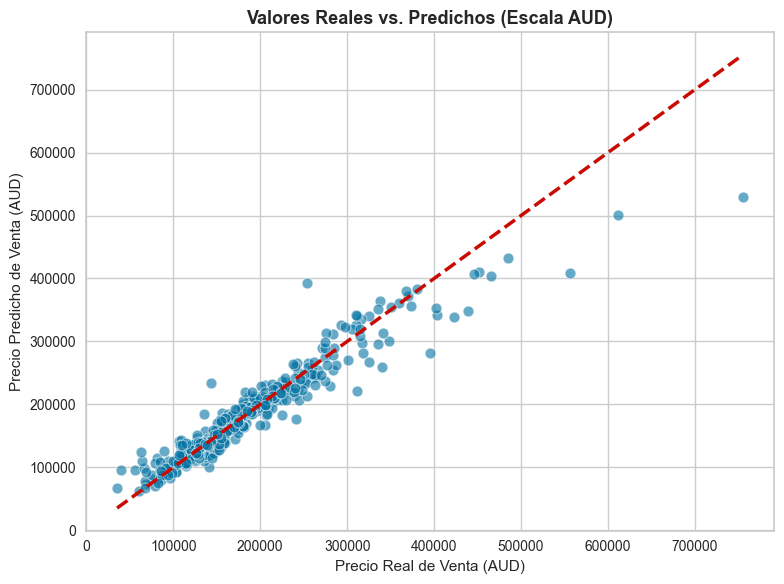

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_true_aud, y=y_pred_aud, alpha=0.6, s=60)
plt.plot(
    [y_true_aud.min(), y_true_aud.max()],
    [y_true_aud.min(), y_true_aud.max()],
    'r--',
    lw=2.5
)
plt.title('Valores Reales vs. Predichos (Escala AUD)', fontsize=13, fontweight='bold')
plt.xlabel('Precio Real de Venta (AUD)', fontsize=11)
plt.ylabel('Precio Predicho de Venta (AUD)', fontsize=11)
plt.tight_layout()
plt.show()


## 7.3 Análisis de residuos
Los residuos permiten revisar si los errores se distribuyen aleatoriamente o si hay sesgos sistemáticos en ciertos rangos de precio.


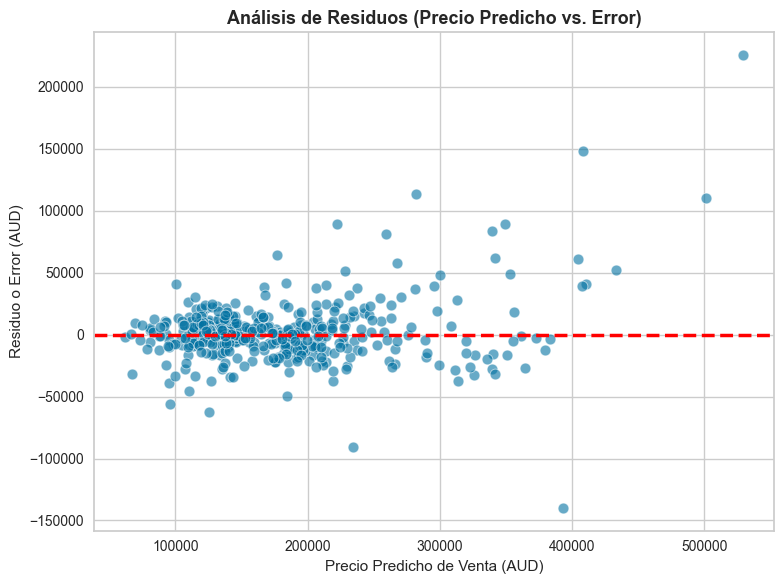

In [17]:
residuals_aud = y_true_aud - y_pred_aud

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_aud, y=residuals_aud, alpha=0.6, s=60)
plt.axhline(y=0, color='red', linestyle='--', lw=2.5)
plt.title('Análisis de Residuos (Precio Predicho vs. Error)', fontsize=13, fontweight='bold')
plt.xlabel('Precio Predicho de Venta (AUD)', fontsize=11)
plt.ylabel('Residuo o Error (AUD)', fontsize=11)
plt.tight_layout()
plt.show()


# 8. Interpretabilidad del Modelo

La interpretabilidad permite convertir el modelo predictivo en recomendaciones de negocio. Se revisa la importancia de variables del modelo final para identificar qué características explican más el precio de venta.

### Lectura de negocio esperada
* `TotalSF` y variables de área explican el tamaño útil de la vivienda.
* `OverallQual` y variables de calidad explican acabados y materiales.
* `HouseAge` y `RemodAge` explican antigüedad y efecto de remodelación.
* `Neighborhood` captura diferencias de ubicación.


## 8.1 Importancia de variables
PyCaret genera el gráfico de importancia de características del modelo seleccionado. Si el modelo no expone importancia directa, PyCaret mostrará el método compatible disponible.


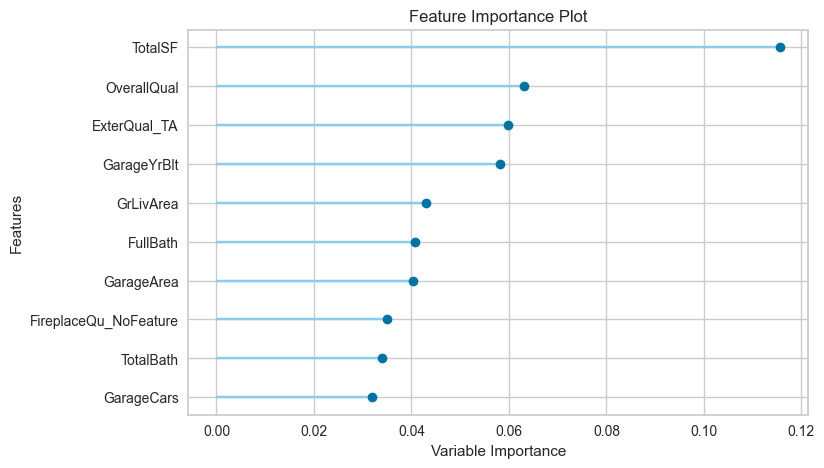

In [18]:
# Plot Feature Importance using PyCaret's default plotting function
plot_model(tuned_best_model, plot='feature')


# 9. Conclusiones y Recomendaciones

### Resultados Obtenidos
1. Se desarrolló un modelo predictivo robusto con un **$R^2$ de 0.9097** sobre el conjunto de test independiente, lo que significa que el modelo captura y explica el **90.97%** del comportamiento de los precios del mercado inmobiliario analizado.
2. El **MAE obtenido es de $15,225.79 AUD** y el **MAPE es de 8.90%**, lo cual indica un margen de error menor al 9% por propiedad en promedio. Esto proporciona una precisión operativa alta para valorar propiedades residenciales.
3. Se determinaron las regularizaciones óptimas en la escala logarítmica:
   * **Ridge óptimo (hiperparámetro $\alpha$/$\lambda$):** `20.0`
   * **Lasso óptimo (hiperparámetro $\alpha$/$\lambda$):** `0.0005`
   * **ElasticNet óptimo (hiperparámetro $\alpha$/$\lambda$):** `0.001` con una proporción L1 de `0.8`.
   * Estos hiperparámetros ayudan a controlar la multicolinealidad sin incurrir en subajuste.

### Limitaciones del Modelo
* **Contexto del Dataset:** el caso de negocio se plantea para Australia, pero el dataset académico usado corresponde a Ames Housing. Por ello, los resultados deben interpretarse como una demostración metodológica del flujo de regresión avanzada.
* **Ausencia de Factores Macroeconómicos:** el modelo no incluye tasas de interés, inflación, desempleo ni ciclos económicos, factores que pueden impactar la demanda inmobiliaria.
* **Datos Georreferenciados:** aunque `Neighborhood` ayuda a segmentar precios, contar con latitud y longitud exactas permitiría modelar proximidad a transporte, parques o zonas comerciales.

### Recomendaciones de Negocio para Surprise Housing
1. **Filtro Automatizado de Inversiones:** usar el modelo para identificar propiedades cuyo precio listado esté significativamente por debajo del valor estimado.
2. **Priorización en Remodelación:** enfocar el presupuesto en acabados de calidad, cocinas y baños, debido al alto impacto de variables como `OverallQual` y `KitchenQual`.
3. **Control del Factor Antigüedad:** adquirir viviendas antiguas con buena estructura y alto potencial de remodelación puede mejorar el margen al reducir el efecto negativo de `RemodAge`.

### Posibles Mejoras Futuras
* Crear un dashboard en Streamlit para ingresar características de una propiedad y obtener una predicción inmediata.
* Agregar variables económicas externas y datos geográficos para mejorar la precisión comercial.
* Implementar un flujo MLOps para reentrenar el modelo periódicamente y monitorear degradación del desempeño.
